## Calibration by temparature scaling

### Imports

In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import Dataset
from tqdm import tqdm

sys.path.append("../services/")
from index import Index

In [ ]:
def retrieve_answer_token_index(tokens):
    for i in range(len(tokens) - 1, 0, -1):
        if tokens[i]["token"].isdigit():
            return i


# field1_text = '"short_chain_of_thoughts": "'
# field2_text = '"answer": "'
def retrieve_reasoning_tokens_range(tokens, start="<think>", end="</think>"):
    start_index, end_index = -1, -1
    tmp_text = ""
    for i in range(len(tokens)):
        if start in tmp_text:
            start_index = i
            break
        tmp_text += tokens[i]["token"]

    tmp_text = ""

    for i in range(len(tokens) - 1, 0, -1):
        tmp_text = tokens[i]["token"] + tmp_text
        if end in tmp_text:
            end_index = i
            break

    return (start_index, end_index)

### Preparation

In [20]:
torch.random.manual_seed(42)

dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test").select(range(12000))
index = Index("../index_data/llama3.1:8b_MMLU-PRO_launch_12000")

In [ ]:
PAD_VAL = 0

VOCAB_SIZE = 20
split_val = len(index) // 2


def process_elements(xs: np.array, ys: np.array):
    processed = {}

    allowed_ids = []
    for i, x in enumerate(xs):
        # Ignoring responses where answer token distribution doesn't have all 0-9 tokens
        log = x["logprobs"][retrieve_answer_token_index(x["logprobs"])]
        if (
            len(
                set([str(x) for x in range(10)]).intersection(
                    set([x["token"] for x in log["top_logprobs"]])
                )
            )
            < 10
        ):
            continue
        allowed_ids.append(i)

    xs = xs[allowed_ids]
    ys = ys[allowed_ids]

    logits = torch.zeros((len(xs), VOCAB_SIZE))
    targets = torch.zeros(len(ys), dtype=torch.long)

    for i, (x, y) in enumerate(zip(xs, ys)):
        answer_token_index = retrieve_answer_token_index(x["logprobs"])
        answer_top_logprobs_tokens = [
            v["token"]
            for v in x["logprobs"][answer_token_index]["top_logprobs"]
        ]
        answer_top_logprobs = torch.tensor(
            [
                v["logprob"]
                for v in x["logprobs"][answer_token_index]["top_logprobs"]
            ]
        )

        max_logprob = answer_top_logprobs.max()
        norm_top_logprobs = answer_top_logprobs - max_logprob

        logits[i] = norm_top_logprobs
        targets[i] = torch.tensor(
            answer_top_logprobs_tokens.index(str(y["answer_index"])),
            dtype=torch.long,
        )

    processed["logits"] = logits
    processed["targets"] = targets

    return processed


class IndexDataset(Dataset):
    def __init__(
        self,
        index: Index,
        dataset: Dataset,
        process_elements=lambda x, y: (x, y),
        split="train",
        load_all_data=False,
        train_split=0.8,
        val_split=0.9,
    ):
        self.index = index
        self.dataset = dataset
        self.split = split
        self.process_elements = process_elements

        if split == "train":
            self.indices = list(range(int(len(index) * train_split)))
        elif split == "val":
            self.indices = list(
                range(
                    int(len(index) * train_split), int(len(index) * val_split)
                )
            )
        else:
            self.indices = list(range(int(len(index) * val_split), len(index)))

        if load_all_data:
            self._load_data()

    def __len__(self):
        return len(self.indices) - 1

    def _load_data(self):
        self.data = self.process_elements(
            np.array(index.load_data(self.indices[0], self.indices[-1])),
            np.array(
                self.dataset.select(range(self.indices[0], self.indices[-1]))
            ),
        )

    def get(self, start=0, end=-1):
        if self.data:
            return {k: v[start:end] for k, v in self.data.items()}

        xs = np.array(
            [
                x
                for x in self.index.load_data(
                    self.indices[start], self.indices[end]
                )
            ]
        )
        ys = np.array(
            self.dataset.select(range(self.indices[start], self.indices[end]))
        )

        return self.process_elements(xs, ys)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = IndexDataset(
    index, dataset, process_elements, split="train", load_all_data=True
)
val = IndexDataset(
    index, dataset, process_elements, split="val", load_all_data=True
)
test = IndexDataset(
    index, dataset, process_elements, split="test", load_all_data=True
)

In [23]:
val_data = val.get()
test_data = test.get()

### Temperature scaling

In [24]:
# Module which will learn temperature value


class TemperatureScaling(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1, device=device))

    def forward(self, logits):
        return torch.div(logits, self.temperature)

In [25]:
# Function to fit temperature value


def fit_temperature_scaling(
    train_data,
    test_data=None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=8,
    epochs=3,
    plot_interval=3,
):
    temperature_model = TemperatureScaling(device)
    optimizer = torch.optim.Adam([temperature_model.temperature], lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, len(train_data) // batch_size, lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in tqdm(range(epochs)):
        for start in range(0, len(train_data) - batch_size, batch_size):
            batch_data = train_data.get(start, start + batch_size)
            if not batch_data:
                continue

            optimizer.zero_grad()
            batch_logits = batch_data["logits"].view(-1, VOCAB_SIZE).to(device)
            batch_labels = batch_data["targets"].view(-1).to(device)
            train_scaled_logits = temperature_model(batch_logits)
            train_loss = torch.nn.functional.cross_entropy(
                train_scaled_logits, batch_labels, ignore_index=PAD_VAL
            )
            train_loss.backward()
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_logits = (
                        test_batch["logits"].view(-1, VOCAB_SIZE).to(device)
                    )
                    test_labels = test_batch["targets"].view(-1).to(device)
                    with torch.no_grad():
                        test_scaled_logits = temperature_model(test_logits)
                        test_loss = torch.nn.functional.cross_entropy(
                            test_scaled_logits,
                            test_labels,
                            ignore_index=PAD_VAL,
                        )
                        test_losses.append(test_loss.item())
                    iterations.append(iteration_counter)

            iteration_counter += 1

    if len(iterations) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return temperature_model.temperature.item()

### Calibration

In [26]:
def calculate_ece_adaptive_bins(probs, targets, n_bins=10, verbose=False):
    token_probs = probs.max(dim=1).values
    accuracies = probs.argmax(dim=-1) == targets

    sorted_indices = torch.argsort(token_probs)
    sorted_probs = token_probs[sorted_indices]
    sorted_accuracies = accuracies[sorted_indices]

    n_samples = len(sorted_probs)
    bin_size = n_samples // n_bins

    ece = torch.zeros(1).to(device)

    if verbose:
        bin_avg_confidences = []
        bin_accuracies_list = []
        bin_conf_min = []
        bin_conf_max = []

    for i in range(n_bins):
        start_idx = i * bin_size
        if i == n_bins - 1:
            end_idx = n_samples
        else:
            end_idx = (i + 1) * bin_size

        if end_idx > start_idx:
            bin_probs = sorted_probs[start_idx:end_idx]
            bin_accuracies = sorted_accuracies[start_idx:end_idx]

            prop_in_bin = (end_idx - start_idx) / n_samples

            if prop_in_bin > 0:
                accuracy_in_bin = bin_accuracies.float().mean()
                avg_confidence_in_bin = bin_probs.mean()
                ece += (
                    torch.abs(avg_confidence_in_bin - accuracy_in_bin)
                    * prop_in_bin
                )

            if verbose:
                bin_avg_confidences.append(
                    avg_confidence_in_bin.detach().cpu()
                )
                bin_accuracies_list.append(accuracy_in_bin.detach().cpu())
                bin_conf_min.append(bin_probs.min().detach().cpu())
                bin_conf_max.append(bin_probs.max().detach().cpu())

    if verbose:
        bin_avg_confidences = torch.stack(bin_avg_confidences).numpy()
        bin_accuracies_list = torch.stack(bin_accuracies_list).numpy()
        bin_conf_min = torch.stack(bin_conf_min).numpy()
        bin_conf_max = torch.stack(bin_conf_max).numpy()

        plt.figure(figsize=(6, 6))

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="gray",
            label="Perfect calibration",
        )

        plt.plot(
            bin_avg_confidences,
            bin_accuracies_list,
            marker="o",
            linewidth=2,
            label="Model (adaptive bins)",
        )

        for i in range(len(bin_accuracies_list)):
            plt.fill_between(
                [
                    bin_conf_min[i] if i > 0 else 0,
                    bin_conf_max[i] if i < len(bin_accuracies_list) - 1 else 1,
                ],
                0,
                bin_accuracies_list[i] + 0.005,
                alpha=0.4,
            )

        plt.xlabel("Confidence")
        plt.ylabel("Accuracy")
        plt.title("Reliability Diagram with Adaptive Bin Coverage")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return ece.item()

### FInding the best temperature on validation data


Trial 1/10: lr_max=0.100000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.38it/s]


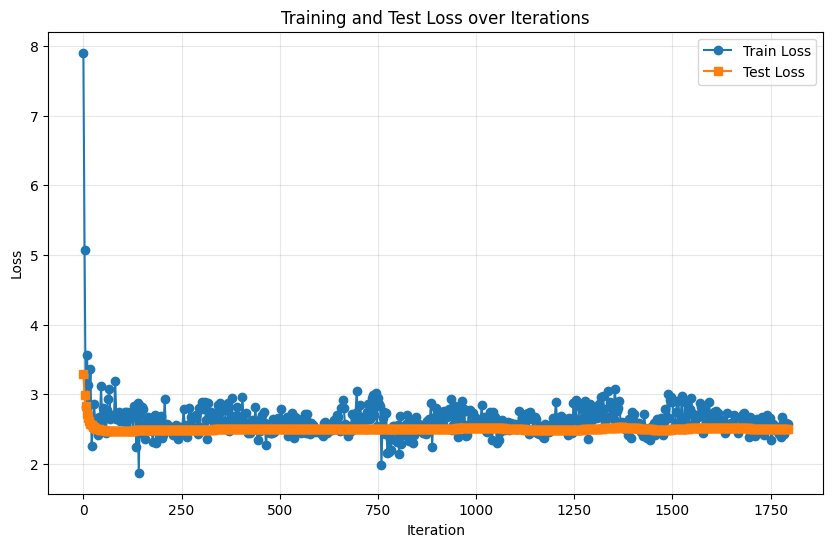

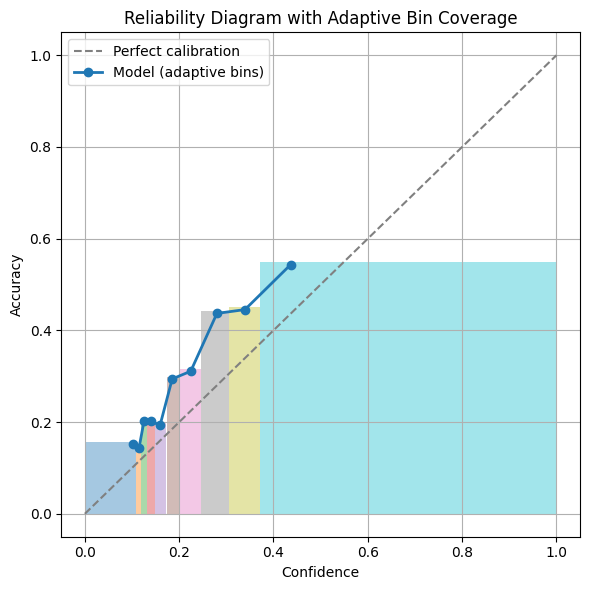

Temperature: 4.9467, ECE: 0.081542

Trial 2/10: lr_max=0.100000, lr_min=0.001000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.49it/s]


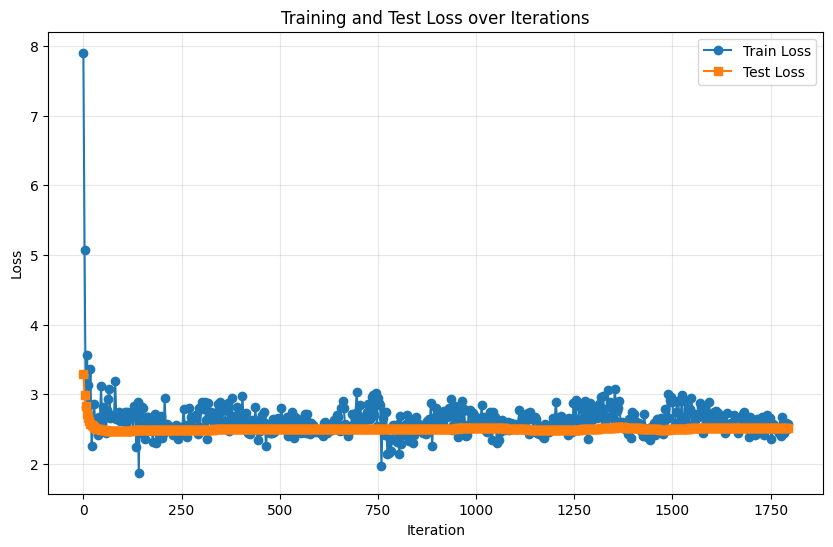

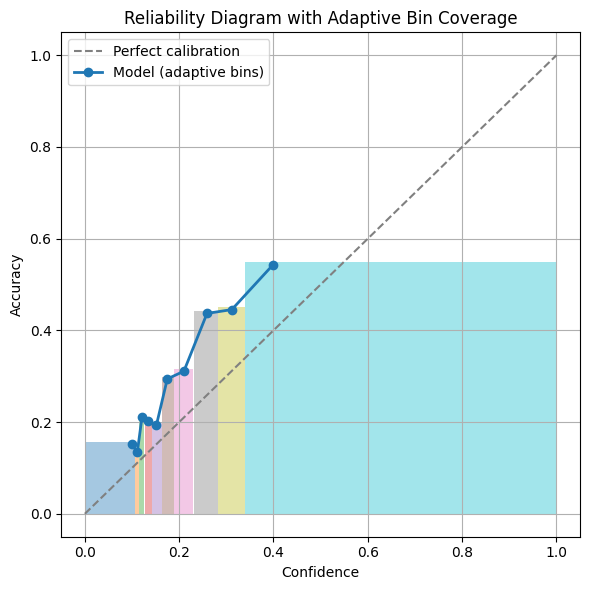

Temperature: 5.2597, ECE: 0.095170

Trial 3/10: lr_max=0.050000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.48it/s]


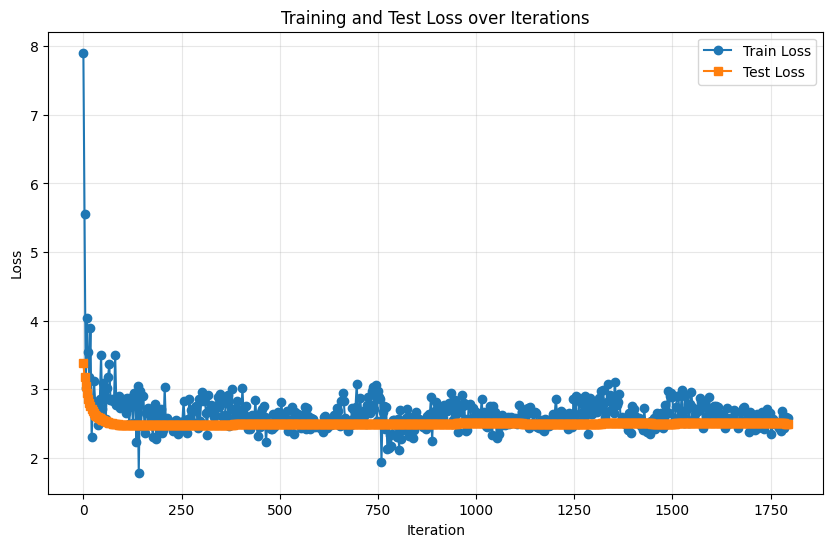

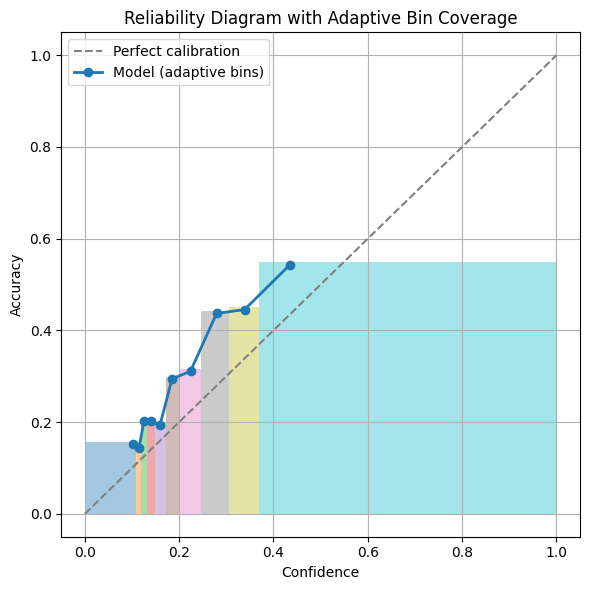

Temperature: 4.9564, ECE: 0.081995

Trial 4/10: lr_max=0.020000, lr_min=0.001000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.40it/s]


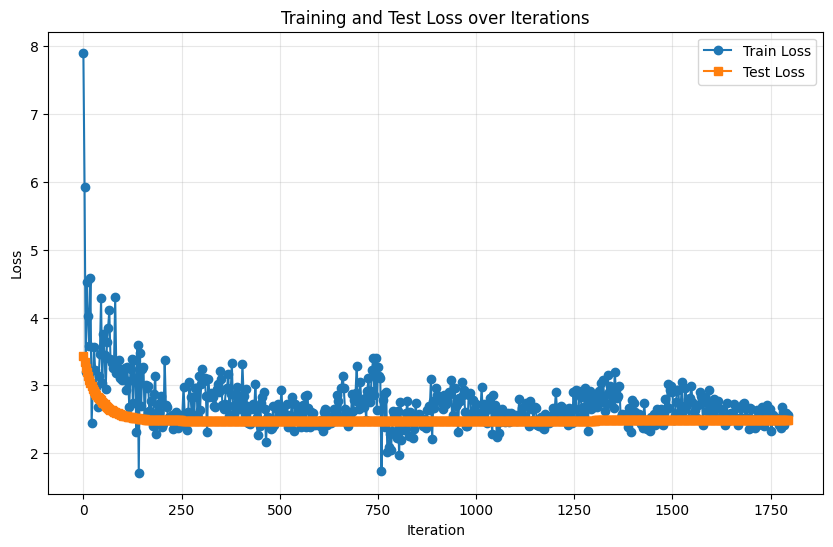

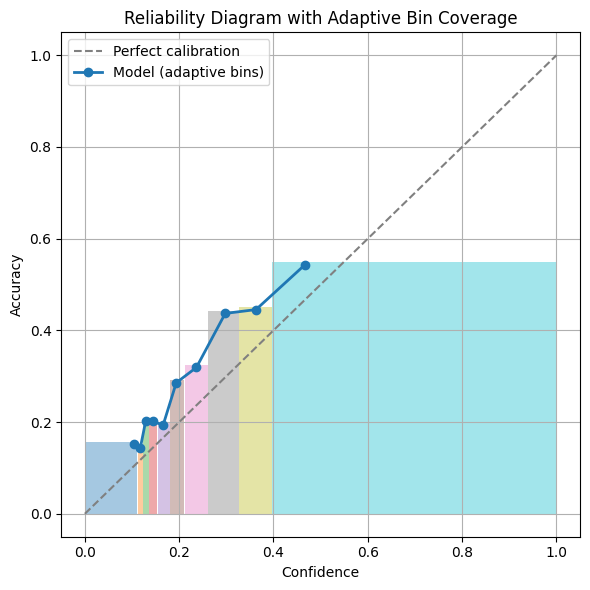

Temperature: 4.7174, ECE: 0.070228

Trial 5/10: lr_max=0.001000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.34it/s]


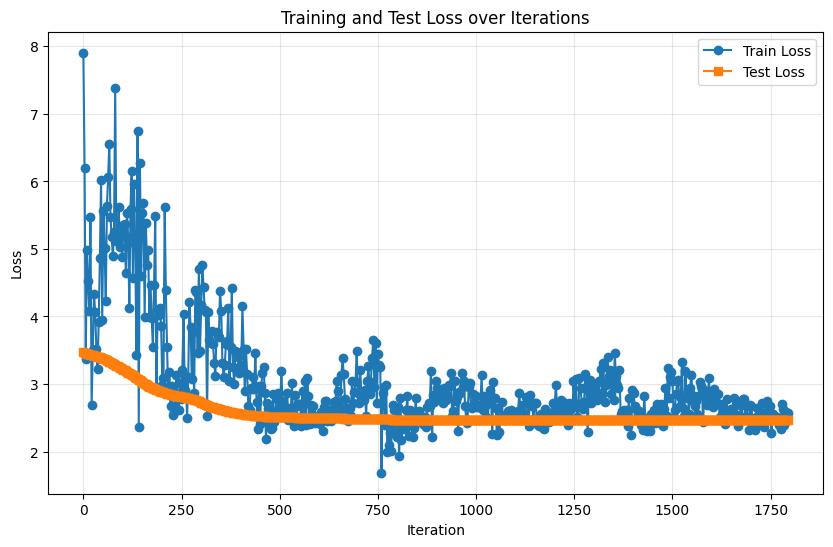

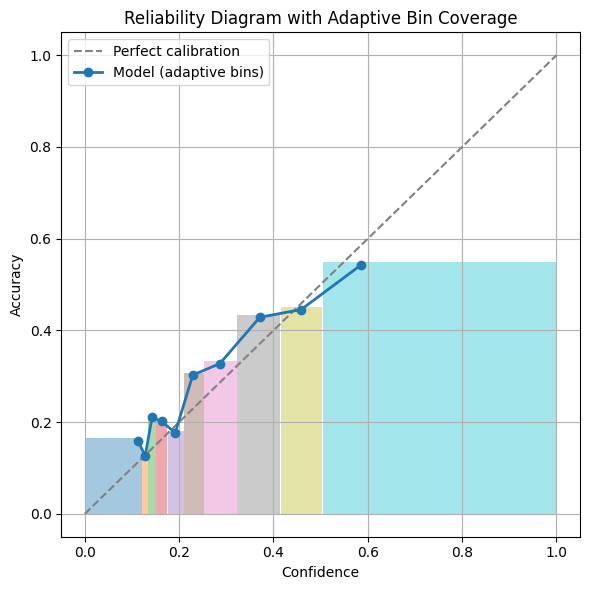

Temperature: 3.9877, ECE: 0.040004

Trial 6/10: lr_max=0.020000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.46it/s]


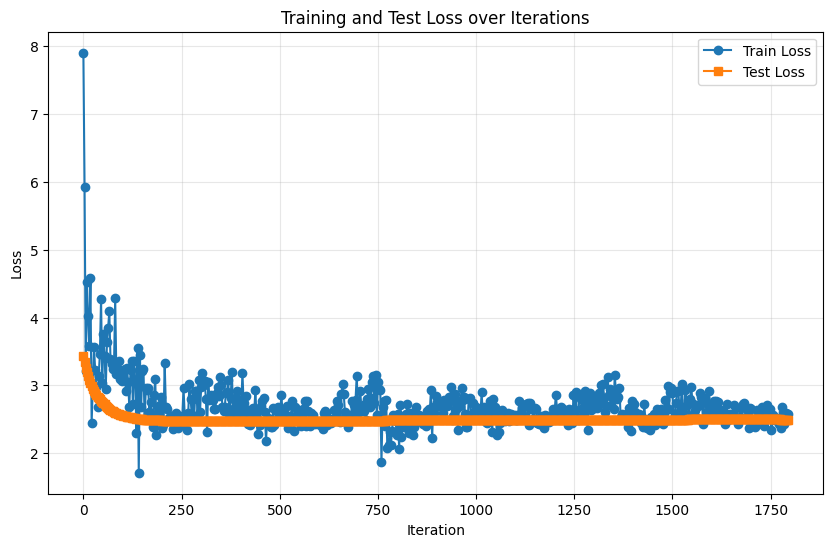

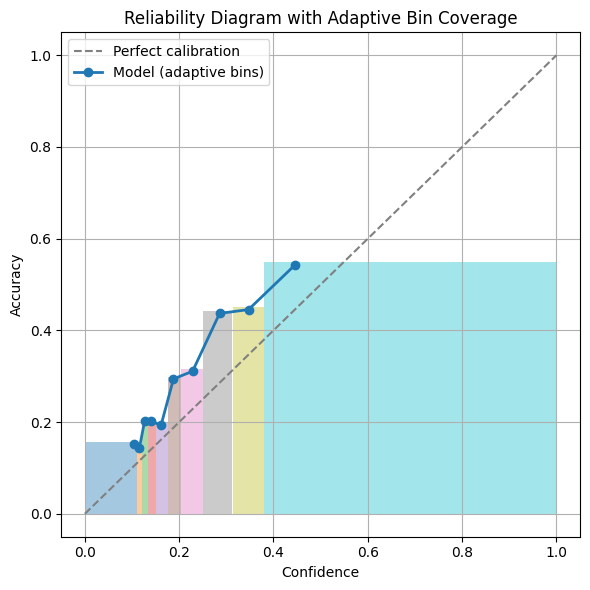

Temperature: 4.8698, ECE: 0.077881

Trial 7/10: lr_max=0.020000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.41it/s]


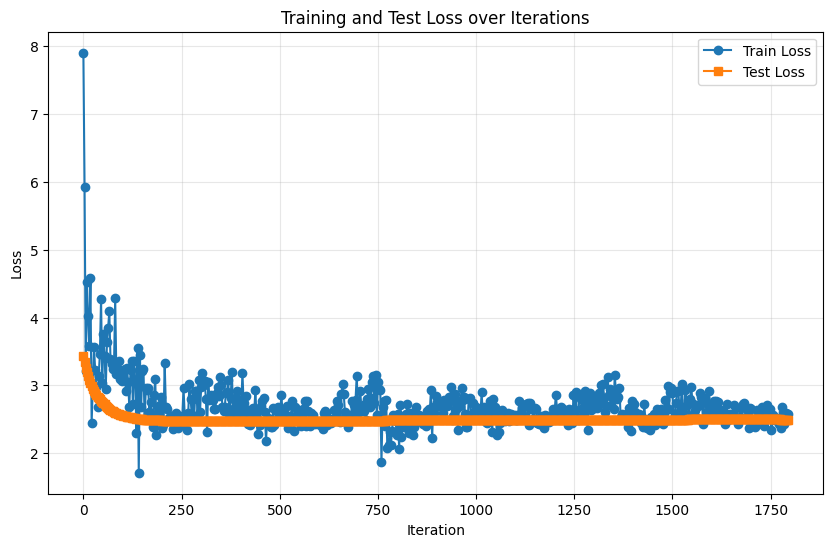

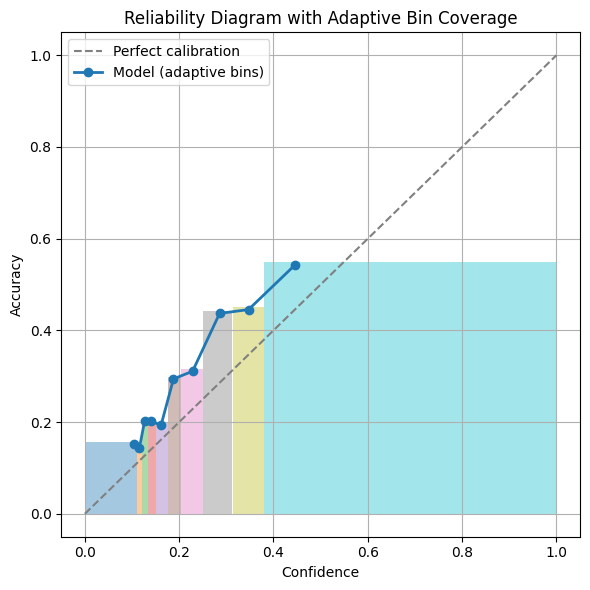

Temperature: 4.8698, ECE: 0.077881

Trial 8/10: lr_max=0.100000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.46it/s]


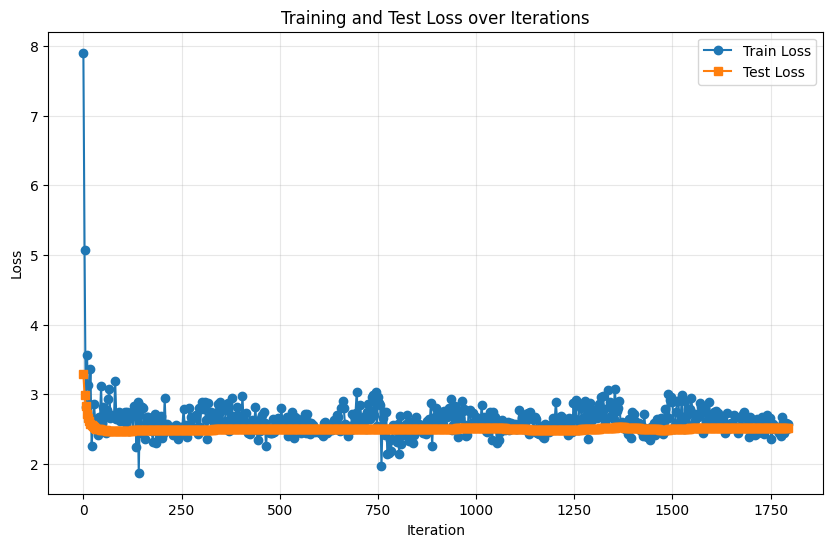

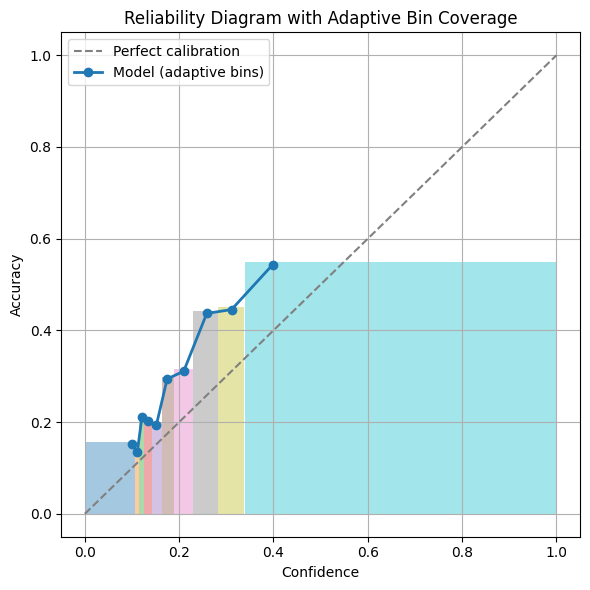

Temperature: 5.2681, ECE: 0.095508

Trial 9/10: lr_max=0.005000, lr_min=0.000100, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.45it/s]


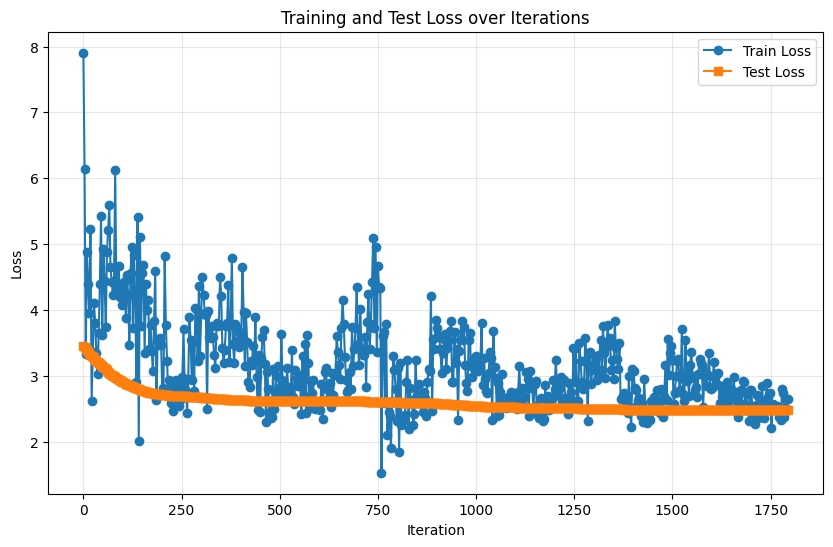

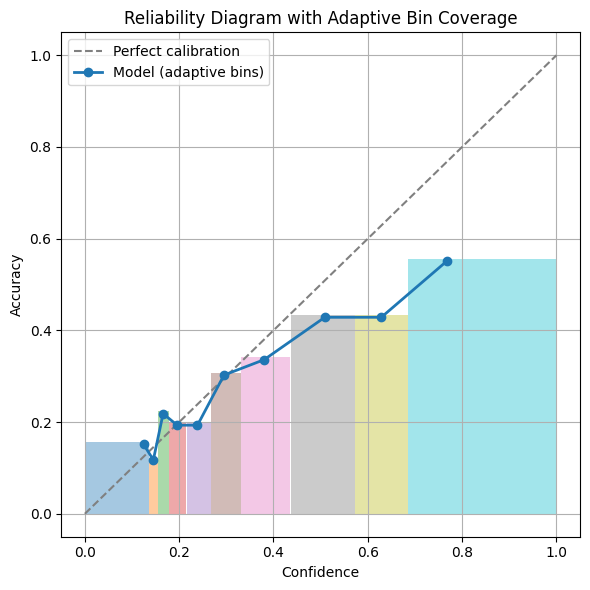

Temperature: 3.1123, ECE: 0.071314

Trial 10/10: lr_max=0.010000, lr_min=0.000100, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.37it/s]


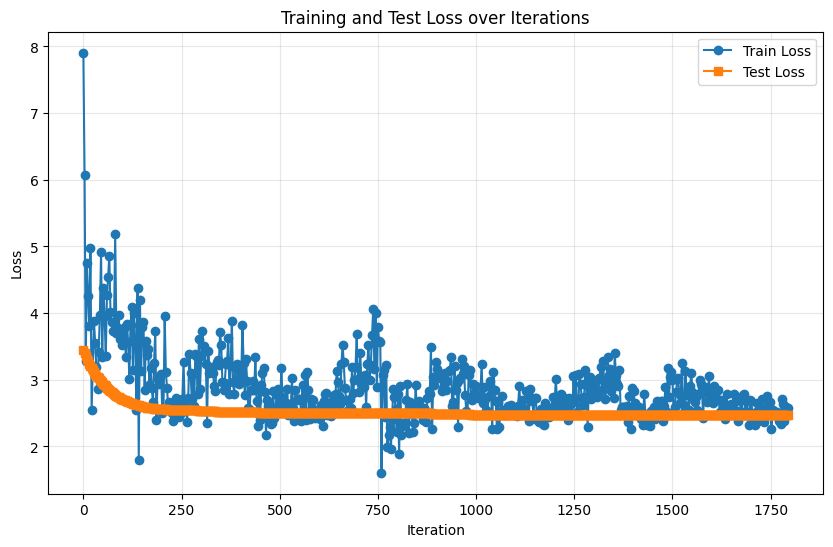

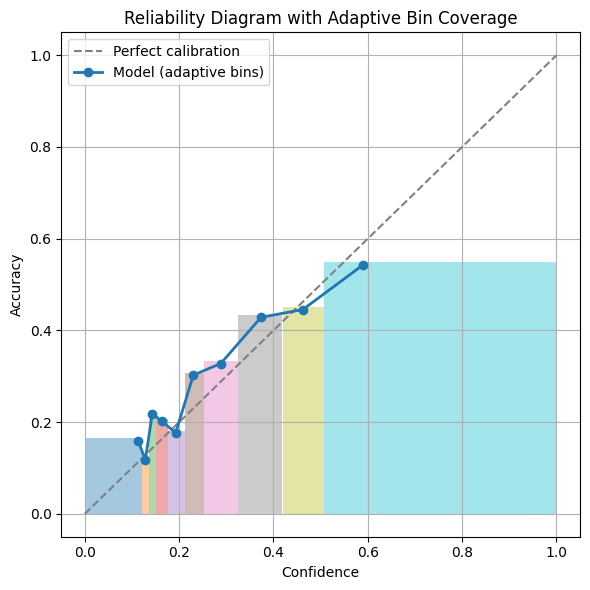

Temperature: 3.9658, ECE: 0.041869

Best ECE on: 0.040004
Best parameters: {'lr_max': np.float64(0.001), 'lr_min': np.float64(0.02), 'batch_size': 16, 'epochs': 3}
Best temperature: 3.9877


In [27]:
TRIALS = 10

results = []

for trial in range(TRIALS):
    lr_max = np.random.choice([1e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1])
    lr_min = np.random.choice([1e-4, 5e-4, 1e-3, 2e-2])
    batch_size = 16
    epochs = 3

    print(
        f"\nTrial {trial + 1}/{TRIALS}: lr_max={lr_max:.6f}, lr_min={lr_min:.6f}, batch_size={batch_size}, epochs={epochs}"
    )

    temperature = fit_temperature_scaling(
        train,
        val,
        lr_max=lr_max,
        lr_min=lr_min,
        batch_size=batch_size,
        epochs=epochs,
    )

    calibrated_logits = [torch.div(x, temperature) for x in val_data["logits"]]
    calibrated_probs = torch.stack(
        [torch.softmax(x, dim=0) for x in calibrated_logits]
    )
    ece = calculate_ece_adaptive_bins(
        calibrated_probs, val_data["targets"], verbose=True
    )

    results.append(
        {
            "params": {
                "lr_max": lr_max,
                "lr_min": lr_min,
                "batch_size": batch_size,
                "epochs": epochs,
            },
            "temperature": temperature,
            "ece": ece,
        }
    )

    print(f"Temperature: {temperature:.4f}, ECE: {ece:.6f}")

best_result = min(results, key=lambda x: x["ece"])

print("\n" + "=" * 60)
print(f"Best ECE on: {best_result['ece']:.6f}")
print(f"Best parameters: {best_result['params']}")
print(f"Best temperature: {best_result['temperature']:.4f}")

### Results

In [28]:
temperature = best_result["temperature"]

calibrated_test_answers_logits = [
    torch.div(x, temperature) for x in test_data["logits"]
]

not_calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in test_data["logits"]]
)
calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in calibrated_test_answers_logits]
)

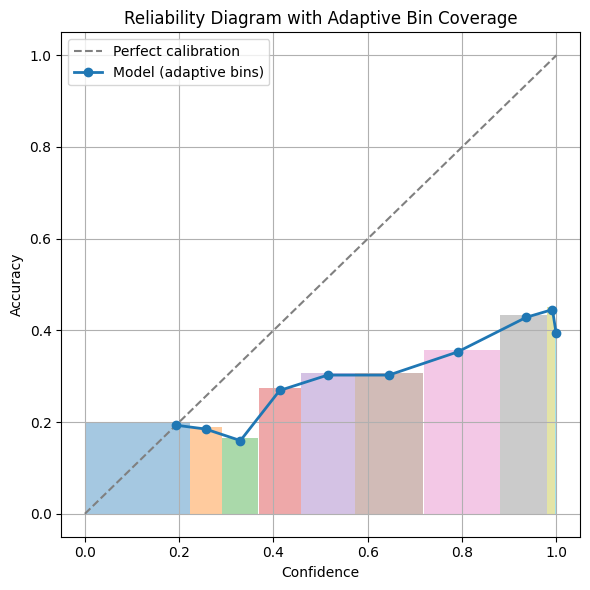

ECE on NON calibrated answer (test data): 0.3057376444339752


In [29]:
print(
    f"ECE on NON calibrated answer (test data): {calculate_ece_adaptive_bins(not_calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

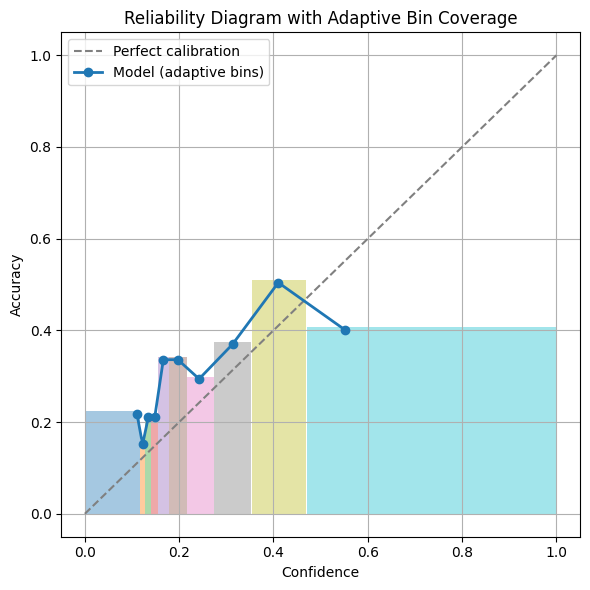

ECE on calibrated answer (test data): 0.09384873509407043


In [30]:
print(
    f"ECE on calibrated answer (test data): {calculate_ece_adaptive_bins(calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

tensor([7.8320e-01, 8.7264e-02, 6.3605e-02, 2.1193e-02, 1.7976e-02, 1.6009e-02,
        6.1122e-03, 4.3101e-03, 2.2671e-04, 6.5489e-05, 9.4142e-06, 4.2822e-06,
        3.6719e-06, 3.2308e-06, 3.1997e-06, 3.1165e-06, 2.9708e-06, 2.6662e-06,
        2.0432e-06, 2.0258e-06])


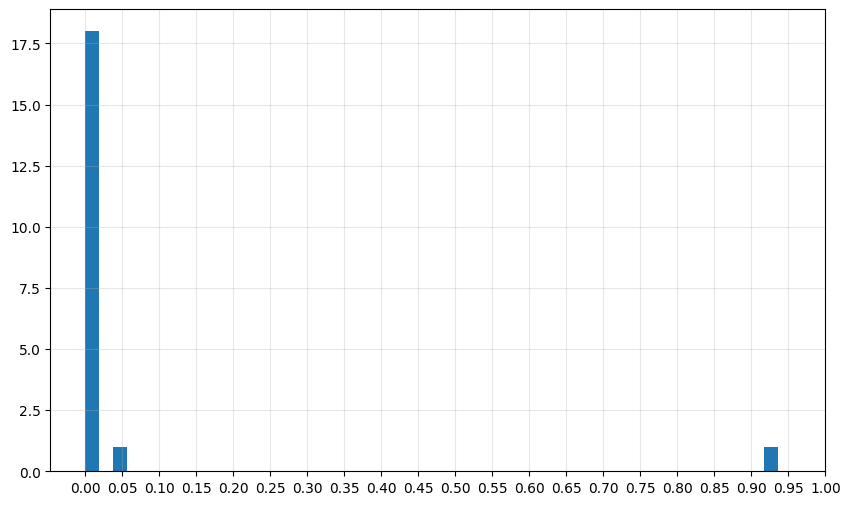

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(not_calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(not_calibrated_test_answers_probs[8])
plt.show()

tensor([0.2211, 0.1275, 0.1178, 0.0894, 0.0858, 0.0834, 0.0655, 0.0600, 0.0287,
        0.0210, 0.0129, 0.0106, 0.0102, 0.0099, 0.0098, 0.0098, 0.0097, 0.0094,
        0.0088, 0.0088])


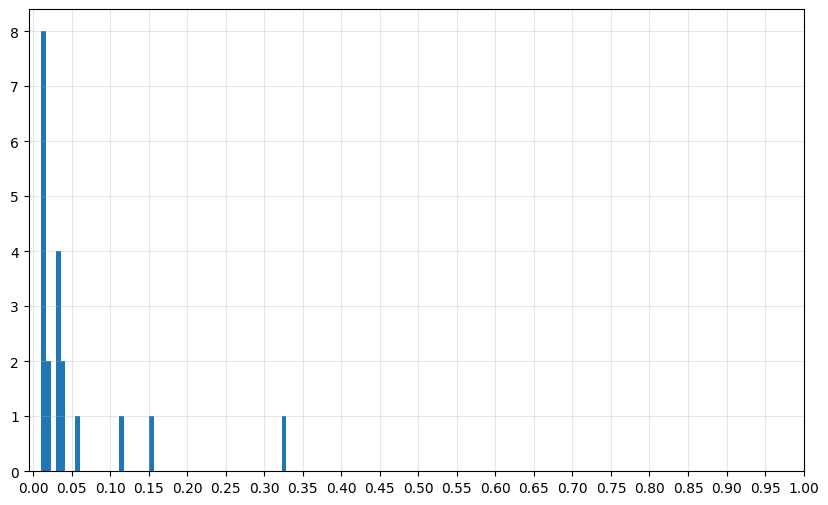

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(calibrated_test_answers_probs[8])
plt.show()

In [33]:
accuracies = (
    not_calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on NON calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on NON calibrated answer: 0.3038397431373596


In [34]:
accuracies = (
    calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on calibrated answer: 0.3038397431373596
